# Selected events — MC/data overlay (cross-section variables)

Overlaid histograms for **fully selected** (`sel_mup`) events, using the cross-section
measurement variables from `unfolding.ipynb` (`var_configs`).

- **Breakdowns**: `topology` and `genie_sb` (same style as `event_selection.ipynb`)
- **Inputs**: configurable MC/data `.df` directories under `DFS_ROOT`
- **Outputs**: saved under `/exp/sbnd/data/users/munjung/PRL_data/`

Headless batch driver: `../scripts/selected_xsec_overlay.py`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings
from datetime import datetime
from functools import partial
from os import makedirs, path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.final_selected_evt_vars import CORE_SELECTED_EVT_VARIABLE_CONFIGS
from analysis_village.numucc_1p0pi import utils as numucc_utils
from analysis_village.numucc_1p0pi.utils import get_pot_str, overlay_hists
_ = numucc_utils  # applies notebooks/presentation.mplstyle
from analysis_village.numucc_1p0pi.utils import get_syst_unc as load_syst_disk_unc
from analysis_village.numucc_1p0pi.utils import _DEFAULT_SYST_DISK_ROOT
from analysis_village.numucc_1p0pi.syst_disk_layout import SYST_DISK_ENV

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
# mplstyle loaded via numucc_utils import above

## Configurable inputs

In [3]:
DFS_ROOT = '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs'
OUTPUT_BASE = '/exp/sbnd/data/users/munjung/PRL_data'

KEYS2LOAD = ['hdr', 'evt']
N_MAX_CONCAT = 999  # data only; MC uses all files with memory guard below
MEMORY_LIMIT_FRAC = 0.60  # retry MC with half the files if exceeded
DATA_POT_SCALE = 1.0  # set 0.9822 if using beam-quality-filtered evt_good

SYST_DISK_ROOT = os.environ.get(SYST_DISK_ENV) or _DEFAULT_SYST_DISK_ROOT
LOAD_SYST = True

APPLY_BEAM_QUALITY = True
FOM_CUT = 0.98
MIN_RUN_DURATION_MIN = 20.0

PLOT_SETS = [
    {
        'tag': 'selected_chi2fix_qual_cut',
        'output_dir': path.join(OUTPUT_BASE, 'selected_chi2fix_qual_cut'),
        'mc_dir': path.join(DFS_ROOT, '2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real'),
        'mc_filename_str': 'sel_mup-mc-fvfix-chi2fix-real',
        'data_dir': path.join(DFS_ROOT, '2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real'),
        'data_filename_str': 'sel_mup-data-1e20-fvfix-chi2fix-real',
    },
    # {
    #     'tag': 'selected_fvfix_qual_cut',
    #     'output_dir': path.join(OUTPUT_BASE, 'selected_fvfix_qual_cut'),
    #     'mc_dir': path.join(DFS_ROOT, '2026_09_01_063924__sel_mup-mc-fvfix'),
    #     'mc_filename_str': 'sel_mup-mc-fvfix',
    #     'data_dir': path.join(DFS_ROOT, '2026_09_01_064250__sel_mup-data-1e20-fvfix'),
    #     'data_filename_str': 'sel_mup-data-1e20-fvfix',
    # },
]

# Same list as unfolding.ipynb var_configs (exclude integrated / all_events)
var_configs = [
    vc for vc in CORE_SELECTED_EVT_VARIABLE_CONFIGS
    if vc.var_save_name != 'integrated'
]
breakdown_types = ['topology', 'genie_sb']

ratio = True
ax_ylim_ratio = 1.9
textloc = [0.03, 0.55]
approval = 'internal'
save_fig = True
plot = False
textchi2 = True

for ps in PLOT_SETS:
    print(ps['tag'], '->', ps['output_dir'])

selected_chi2fix_qual_cut -> /exp/sbnd/data/users/munjung/PRL_data/selected_chi2fix_qual_cut


## Helpers

In [4]:
def get_syst_cov(var_config):
    if not LOAD_SYST:
        return None
    try:
        frac_unc, cov = load_syst_disk_unc(
            var_config, syst_disk_root=SYST_DISK_ROOT, skip_missing_vars=True,
        )
        return cov
    except Exception as ex:
        print(f'  syst skip {var_config.var_save_name}: {ex}')
        return None


def load_sample(sample_dir, filename_str):
    dfs = dfs_from_dir(
        sample_dir,
        filename_str=filename_str,
        keys2load=KEYS2LOAD,
        n_max_concat=N_MAX_CONCAT,
    )
    evt, hdr = dfs['evt'], dfs['hdr']
    if 'mc' in evt.columns.get_level_values(0):
        evt.loc[evt.mc.iscc.isna(), ('mc', 'iscc')] = 999
    return evt, hdr


def setup_pot_weights(mc_evt, mc_hdr, data_evt, data_hdr):
    data_tot_pot = data_hdr['pot'].sum() * DATA_POT_SCALE
    pot_str = get_pot_str(data_tot_pot)
    data_evt['pot_weight'] = np.ones(len(data_evt))
    mc_tot_pot = mc_hdr['pot'].sum()
    mc_scale = data_tot_pot / mc_tot_pot
    mc_evt['pot_weight'] = mc_scale * np.ones(len(mc_evt))
    print(f'  data POT={data_tot_pot:.3e}  MC POT={mc_tot_pot:.3e}  scale={mc_scale:.3e}')
    print(f'  evt rows: data={len(data_evt):,}  mc={len(mc_evt):,}')
    return f'Events / Bin (POT={pot_str})'

## Run all configured sets

In [5]:
t0 = datetime.now()
print('start', t0.isoformat())

for plot_set in PLOT_SETS:
    tag = plot_set['tag']
    out_dir = plot_set['output_dir']
    print('\n' + '=' * 72)
    print('Plot set:', tag)
    print('  MC:  ', plot_set['mc_dir'])
    print('  data:', plot_set['data_dir'])
    if save_fig:
        makedirs(out_dir, exist_ok=True)
        print('  saving ->', out_dir)

    mc_evt, mc_hdr = load_sample(plot_set['mc_dir'], plot_set['mc_filename_str'])
    data_evt, data_hdr = load_sample(plot_set['data_dir'], plot_set['data_filename_str'])
    pot_label = setup_pot_weights(mc_evt, mc_hdr, data_evt, data_hdr)

    data_vs_mc_plotter = partial(
        overlay_hists,
        mc_df=mc_evt,
        data_df=data_evt,
        intime_df=None,
        dirt_df=None,
        ax_ylim_ratio=ax_ylim_ratio,
        ratio=ratio,
        textloc=textloc,
        approval=approval,
        save_fig=save_fig,
        plot=plot,
    )

    for var_config in var_configs:
        syst = get_syst_cov(var_config)
        for breakdown_type in breakdown_types:
            save_name = path.join(out_dir, f"{var_config.var_save_name}_{breakdown_type}")
            plot_labels_hist = [var_config.var_labels[1], pot_label, '']
            print(f'  {var_config.var_save_name} ({breakdown_type})')
            data_vs_mc_plotter(
                breakdown_type=breakdown_type,
                var_config=var_config,
                plot_labels=plot_labels_hist,
                syst=syst,
                textchi2=textchi2,
                save_name=save_name,
            )

print('\nDone in', datetime.now() - t0)

start 2026-09-06T03:03:37.093831

Plot set: selected_chi2fix_qual_cut
  MC:   /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real
  data: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real
  saving -> /exp/sbnd/data/users/munjung/PRL_data/selected_chi2fix_qual_cut
Found 999 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real/sel_mup-mc-fvfix-chi2fix-real_100.df', '/pnfs/sbnd/scratch/users/munjung/ca

100%|██████████| 999/999 [08:01<00:00,  2.08it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 100 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_13.df', '

100%|██████████| 100/100 [00:44<00:00,  2.26it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
  data POT=8.967e+19  MC POT=2.811e+20  scale=3.190e-01
  evt rows: data=12,967  mc=37,076
  muon-p (topology)
No intime cosmics provided
  muon-p (genie_sb)
No intime cosmics provided
  muon-dir_z (topology)
No intime cosmics provided
  muon-dir_z (genie_sb)
No intime cosmics provided
  proton-p (topology)
No intime cosmics provided
  proton-p (genie_sb)
No intime cosmics provided
  proton-dir_z (topology)
No intime cosmics provided
  proton-dir_z (genie_sb)
No intime cosmics provided
  tki-del_Tp (topology)
No intime cosmics provided
  tki-del_Tp (genie_sb)
No intime cosmics provided
  tki-del_Tp_x (topology)
No intime cosmics provided
  tki-del_Tp_x (genie_sb)
No intime cosmics provided
  tki-del_Tp_y (topology)
No intime cosmics provided
  tki-del_Tp_y (genie_sb)
No intime cosmics provided
  tki-del_p (topology)
No intime cosmics provided
  tki-del_p (genie_sb)
No intime cosmics provided
  tki-del_alpha (topology)
No intime cosmics provide

# Test a specific set of samples

In [6]:
plot_set = PLOT_SETS[0]
print(plot_set)

tag = plot_set['tag']
out_dir = plot_set['output_dir']
print('\n' + '=' * 72)
print('Plot set:', tag)
print('  MC:  ', plot_set['mc_dir'])
print('  data:', plot_set['data_dir'])
if save_fig:
    makedirs(out_dir, exist_ok=True)
    print('  saving ->', out_dir)

# mc_evt, mc_hdr = load_sample(plot_set['mc_dir'], plot_set['mc_filename_str'])
data_evt, data_hdr = load_sample(plot_set['data_dir'], plot_set['data_filename_str'])
pot_label = setup_pot_weights(mc_evt, mc_hdr, data_evt, data_hdr)

{'tag': 'selected_chi2fix_qual_cut', 'output_dir': '/exp/sbnd/data/users/munjung/PRL_data/selected_chi2fix_qual_cut', 'mc_dir': '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real', 'mc_filename_str': 'sel_mup-mc-fvfix-chi2fix-real', 'data_dir': '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real', 'data_filename_str': 'sel_mup-data-1e20-fvfix-chi2fix-real'}

Plot set: selected_chi2fix_qual_cut
  MC:   /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_01_063545__sel_mup-mc-fvfix-chi2fix-real
  data: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real
  saving -> /exp/sbnd/data/users/munjung/PRL_data/selected_chi2fix_qual_cut
Found 100 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_09_02_182019__sel_mup-data-1e20-fvfix-chi2fix-real/sel_mup-data-1e20-fvfix-chi2fix-real_0.df', '/pnf

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:20<00:00,  4.94it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
  data POT=8.967e+19  MC POT=2.811e+20  scale=3.190e-01
  evt rows: data=12,967  mc=37,076


In [7]:
def avg_chi2(df, var_name):
    planes = ['I0', 'I1', 'I2']
    chi2_vals = []
    for plane in planes:
        chi2 = df['pfp']['trk']['chi2pid'][plane][var_name]
        chi2_vals.append(chi2)
    chi2_df = pd.concat(chi2_vals, axis=1)

    chi2_df = chi2_df.replace(0, np.nan)
    avg = chi2_df.mean(axis=1, skipna=True)
    return avg

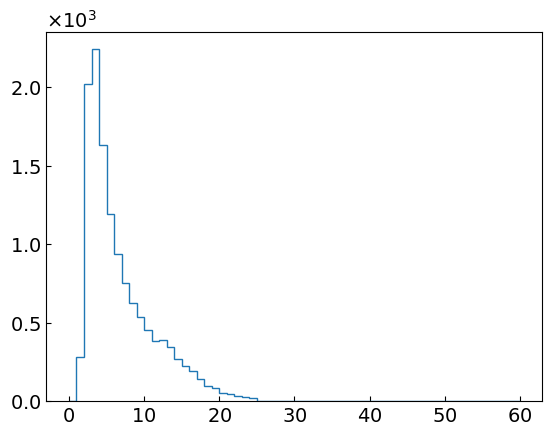

In [8]:
score_tag = ""
chimu_avg = avg_chi2(data_evt.mu, f"chi2_muon{score_tag}")
var = chimu_avg
bins = np.linspace(0, 60, 61)
plt.hist(var, bins=bins, histtype='step')
plt.show()

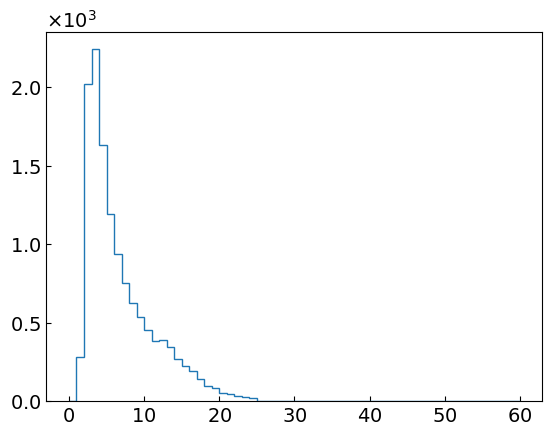

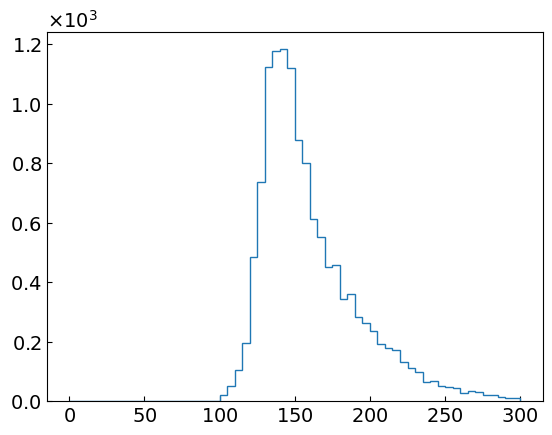

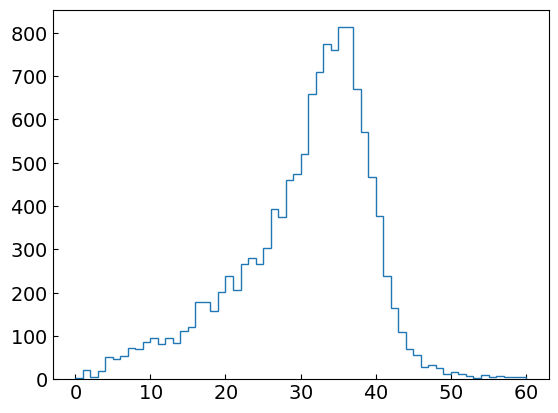

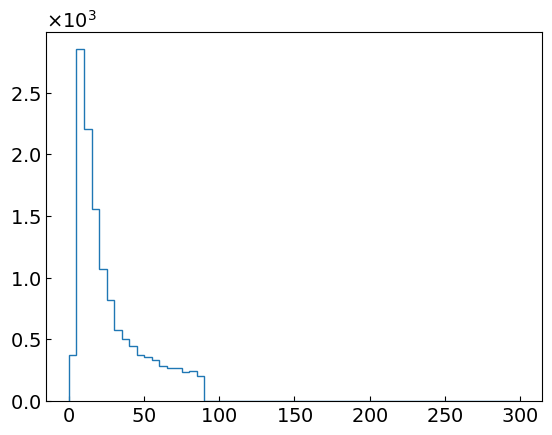

In [9]:
score_tag = ""
chimu_avg = avg_chi2(data_evt.mu, f"chi2_muon{score_tag}")
var = chimu_avg
bins = np.linspace(0, 60, 61)
plt.hist(var, bins=bins, histtype='step')
plt.show()

score_tag = ""
chimu_avg = avg_chi2(data_evt.mu, f"chi2_proton{score_tag}")
var = chimu_avg
bins = np.linspace(0, 300, 61)
plt.hist(var, bins=bins, histtype='step')
plt.show()

score_tag = ""
chimu_avg = avg_chi2(data_evt.p, f"chi2_muon{score_tag}")
var = chimu_avg
bins = np.linspace(0, 60, 61)
plt.hist(var, bins=bins, histtype='step')
plt.show()

score_tag = ""
chimu_avg = avg_chi2(data_evt.p, f"chi2_proton{score_tag}")
var = chimu_avg
bins = np.linspace(0, 300, 61)
plt.hist(var, bins=bins, histtype='step')
plt.show()

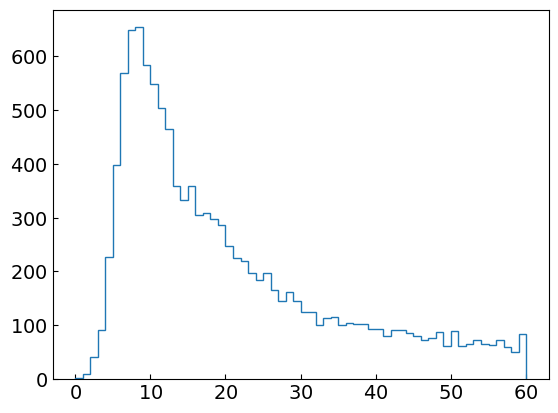

In [10]:
var = chimu_avg
bins = np.linspace(0, 60, 61)
plt.hist(var, bins=bins, histtype='step')
plt.show()

In [11]:
mc_evt.pot_weight

__ntuple  entry  rec.slc..index
5         9      0                 0.319032
0         12     0                 0.319032
2         16     1                 0.319032
13        8      0                 0.319032
17        22     0                 0.319032
                                     ...   
186795    12     0                 0.319032
186797    14     2                 0.319032
186802    7      0                 0.319032
186803    3      3                 0.319032
186811    19     1                 0.319032
Name: pot_weight, Length: 37076, dtype: float64

In [12]:
print(len(mc_evt) * 0.319032)
print(len(data_evt))

print(len(mc_evt) * 0.319032 / len(data_evt))
print(len(mc_evt[mc_evt.slc.vertex.x < 0]) * 0.319032 / len(data_evt[data_evt.slc.vertex.x < 0]))
print(len(mc_evt[mc_evt.slc.vertex.x > 0]) * 0.319032 / len(data_evt[data_evt.slc.vertex.x > 0]))

11828.430432
12967
0.912194835505514
0.9209028797527047
0.9035229798368477


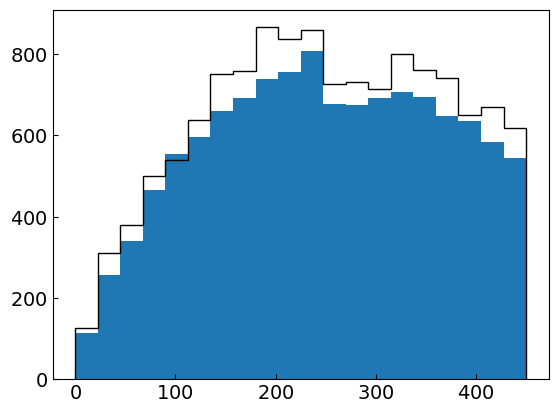

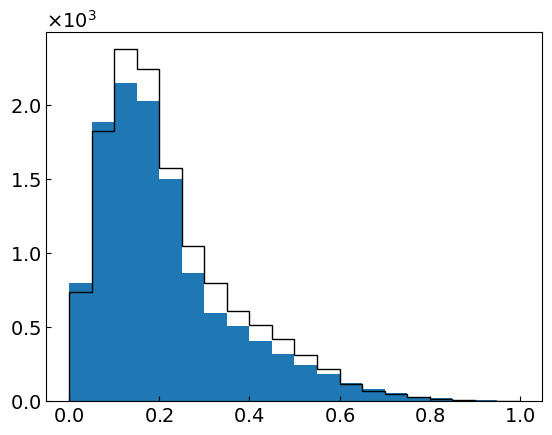

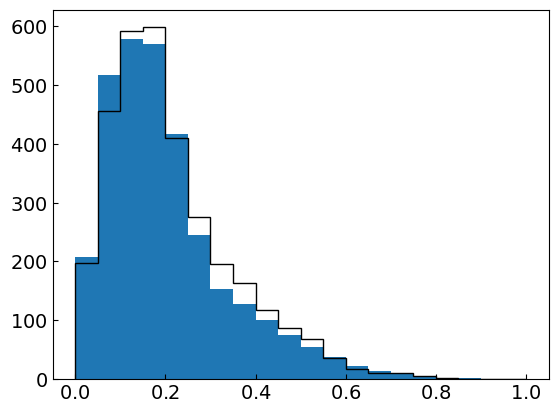

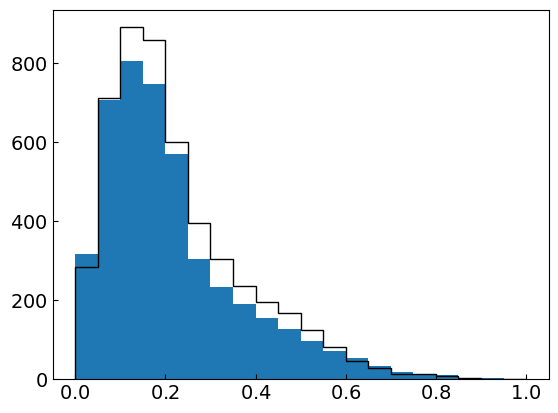

In [27]:
bins = np.linspace(0,450,21)
var = mc_evt.mu.pfp.trk.end.z
plt.hist(var, bins=bins, weights=mc_evt.pot_weight) #, histtype='step')
var = data_evt.mu.pfp.trk.end.z
plt.hist(var, bins=bins, histtype='step', color="k")
plt.show()

bins = np.linspace(0,1,21)
var = mc_evt.del_Tp
plt.hist(var, bins=bins, weights=mc_evt.pot_weight) #, histtype='step')
var = data_evt.del_Tp
plt.hist(var, bins=bins, histtype='step', color="k")
plt.show()

bins = np.linspace(0,1,21)
var = mc_evt[np.abs(mc_evt.p.pfp.trk.dir.y) < 0.2].del_Tp
plt.hist(var, bins=bins, weights=mc_evt[np.abs(mc_evt.p.pfp.trk.dir.y) < 0.2].pot_weight) #, histtype='step')
var = data_evt[np.abs(data_evt.p.pfp.trk.dir.y) < 0.2].del_Tp
plt.hist(var, bins=bins, histtype='step', color="k")
plt.show()

bins = np.linspace(0,1,21)
var = mc_evt[mc_evt.p.pfp.trk.dir.y > 0.2].del_Tp
plt.hist(var, bins=bins, weights=mc_evt[mc_evt.p.pfp.trk.dir.y > 0.2].pot_weight) #, histtype='step')
var = data_evt[data_evt.p.pfp.trk.dir.y > 0.2].del_Tp
plt.hist(var, bins=bins, histtype='step', color="k")
plt.show()

In [ ]:
var_config = VariableConfig.muon_momentum()

eps = 1e-8
ratio = True
approval = ""
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

ret = overlay_hists(breakdown_type=breakdown_type,
                    var_config=var_config,
                    mc_df=mc_df,
                    data_df=data_df,
                    intime_df=intime_df,
                    dirt_df=dirt_df,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    textloc=textloc,
                    approval=approval,
                    plot_labels=plot_labels_hist,
                    syst=None,
                    save_fig=False, 
                    save_name=None)